In [2]:
import os
import numpy as np
import glob
import xarray as xr
import museval
from museval.utils import get_response, find_response, aia_synthesis, wavelength_in_cube
from muse.synthesis.synthesis import transform_resp_units
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import re
from pathlib import Path
from astropy.time import Time
from museval.io import create_session, is_complete, extract_remote_str, files_to_retry
import sunpy.map
import sunpy.visualization.colormaps as cm
import eispac
import astropy.units as u
from astropy.coordinates import SkyCoord
from aiapy.psf import deconvolve, psf

In [18]:
from tqdm import tqdm


xdim_bifrost_QS = 34 # this is the x-dimension of the Bifrost QS FOV in arcsec
ydim_bifrost_QS = 34 # this is the y-dimension of the Bifrost QS FOV in arcsec

e_mail = 'sbose925@gmail.com'
os.environ['exist_data_path'] = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/'
str_prefix = 'SDO_EIS_cutouts_'

os.environ['aia_npz_data'] = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/'
str_prefix_npz = 'QS_AIA_'
aia_data_npz = sorted(glob.glob(os.environ['aia_npz_data'] + str_prefix_npz + '*.npz'))
PSF_aia_team = np.load('/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/AIA_PSFs/aia_psfs_added.npz',allow_pickle=True)
for idx, file in tqdm(enumerate((aia_data_npz))):
    # print(idx)
    s = file
    stem = Path(s).stem
    m = re.search(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", stem)
    dt_str = m.group(0) if m else None
    aia_fdisk_path = os.path.join(os.environ['exist_data_path'], str_prefix + dt_str)
    try:
        assert os.path.exists(aia_fdisk_path)
    except AssertionError:
        print(f"Path does not exist: {aia_fdisk_path}")
    eis_data_h5 = glob.glob(aia_fdisk_path + '/*.data.h5')
    data = eispac.read_cube(eis_data_h5[0])
    bottom_left = SkyCoord((data.meta['mod_index']['xcen'] - xdim_bifrost_QS/2)*u.arcsec, (data.meta['mod_index']['ycen'] - ydim_bifrost_QS/2)*u.arcsec, frame='helioprojective', obstime=data.meta['mod_index']['date_obs'],observer="earth")
    top_right = SkyCoord((data.meta['mod_index']['xcen'] + xdim_bifrost_QS/2)*u.arcsec, (data.meta['mod_index']['ycen'] + ydim_bifrost_QS/2)*u.arcsec, frame='helioprojective', obstime=data.meta['mod_index']['date_obs'],observer="earth")
    
    os.makedirs(aia_fdisk_path+'/bigger_sdo_cutouts', exist_ok=True)
    sdo_fits_files = sorted(
    glob.glob(aia_fdisk_path + '/aia.*.fits') +
    glob.glob(aia_fdisk_path + '/hmi.*.fits')
    )
    for idx, ff in enumerate(sdo_fits_files):
        maps = sunpy.map.Map(ff)
        # print(int(maps.wavelength.value))
        if ff == sdo_fits_files[-1]:
            out_hmi = maps.reproject_to(sunpy.map.Map(sdo_fits_files[0]).wcs) #to co-align HMI with AIA
            maps_new_cutout = out_hmi.submap(bottom_left, top_right=top_right)
            maps_new_cutout.meta['telescop'] = 'SDO/HMI'
            maps_new_cutout.meta['wavelnth'] = '6173'
            maps_new_cutout.save(aia_fdisk_path+'/bigger_sdo_cutouts/'+Path(ff).name, overwrite=True)
        else:
            # continue
            wav = int(maps.wavelength.value)
            maps_deconvolved = deconvolve(maps, psf=PSF_aia_team['psf'+str(wav)])
            maps_new_cutout = maps_deconvolved.submap(bottom_left, top_right=top_right)
            maps_new_cutout.save(aia_fdisk_path+'/bigger_sdo_cutouts/'+Path(ff).name, overwrite=True)
 

0it [00:00, ?it/s]

Data file,
   /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2014-04-28T13:22:00/eis_20140428_140915.data.h5
Header file,
   /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2014-04-28T13:22:00/eis_20140428_140915.head.h5
Found window 0


2026-04-03 23:16:38 - sunpy - INFO: cupy not installed or working, falling back to CPU


INFO: cupy not installed or working, falling back to CPU [aiapy.psf.deconvolve]


2026-04-03 23:16:49 - astropy - WARNING: VerifyWarning: Invalid 'BLANK' keyword in header.  The 'BLANK' keyword is only applicable to integer data, and will be ignored in this HDU.
2026-04-03 23:16:49 - sunpy - INFO: cupy not installed or working, falling back to CPU


...

2026-04-03 23:21:14 - astropy - WARNING: VerifyWarning: Invalid 'BLANK' keyword in header.  The 'BLANK' keyword is only applicable to integer data, and will be ignored in this HDU.
2026-04-03 23:21:15 - sunpy - INFO: cupy not installed or working, falling back to CPU


INFO: cupy not installed or working, falling back to CPU [aiapy.psf.deconvolve]


2026-04-03 23:21:25 - astropy - WARNING: VerifyWarning: Invalid 'BLANK' keyword in header.  The 'BLANK' keyword is only applicable to integer data, and will be ignored in this HDU.
2026-04-03 23:21:25 - sunpy - INFO: cupy not installed or working, falling back to CPU


INFO: cupy not installed or working, falling back to CPU [aiapy.psf.deconvolve]


2026-04-03 23:21:36 - astropy - WARNING: VerifyWarning: Invalid 'BLANK' keyword in header.  The 'BLANK' keyword is only applicable to integer data, and will be ignored in this HDU.
2026-04-03 23:21:36 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-04-03 23:21:43 - astropy - WARNING: VerifyWarning: Verification reported errors:
2026-04-03 23:21:43 - astropy - WARNING: VerifyWarning: HDU 0:
2026-04-03 23:21:43 - astropy - WARNING: VerifyWarning:     'NAXIS1' card at the wrong place (card 29).  Fixed by moving it to the right place (card 3).
2026-04-03 23:21:43 - astropy - WARNING: VerifyWarning:     'NAXIS2' card at the wrong place (card 30).  Fixed by moving it to the right place (card 4).
 [astropy.io.fits.verify]
2026-04-03 23:21:43 - astropy - WARNING: VerifyWarning: Note: astropy.io.fits uses zero-based indexing.

5it [05:05, 61.08s/it]


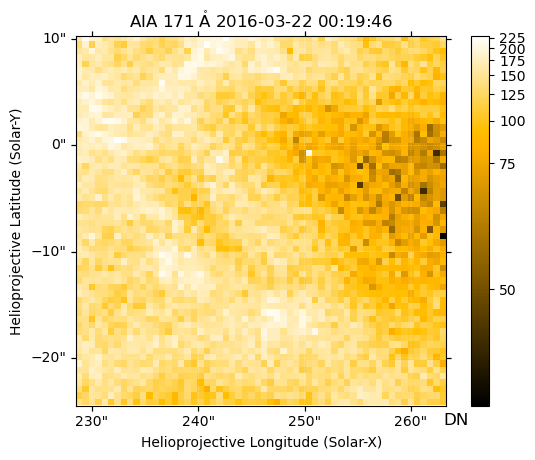

In [20]:
test_dpath = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2016-03-22T00:18:40'+'/bigger_sdo_cutouts/'
test_cut_out_map = sunpy.map.Map(test_dpath + 'aia.lev1_euv_12s.2016-03-22T001947Z.171.image_lev1.fits')
test_cut_out_map.peek()

Observatory,SDO
Instrument,AIA 3
Detector,AIA
Measurement,171.0 Angstrom
Wavelength,171.0 Angstrom
Observation Date,2016-03-22 00:19:46
Exposure Time,2.000164 s
Dimension,[58. 58.] pix
Coordinate System,helioprojective
Scale,[0.59948897 0.59948897] arcsec / pix
Reference Pixel,[-381.70996 40.46997] pix

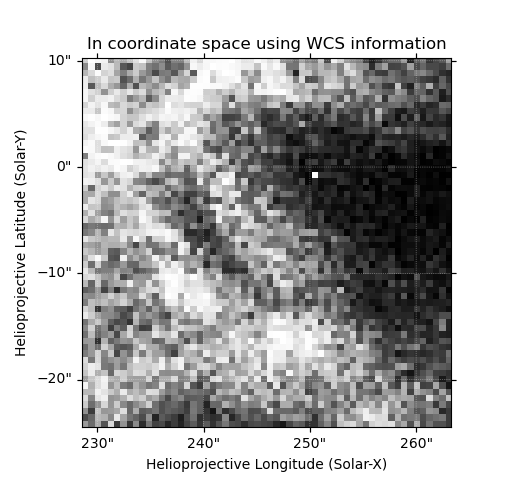
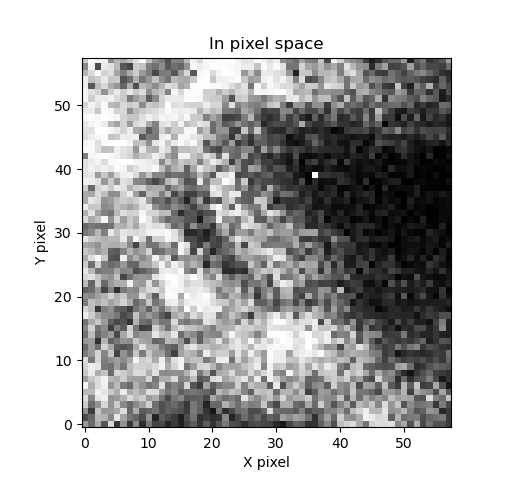
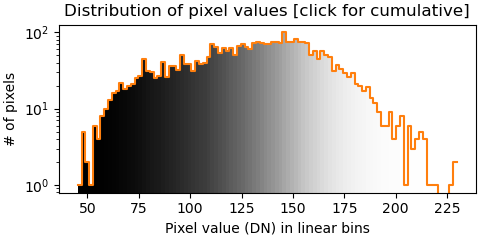
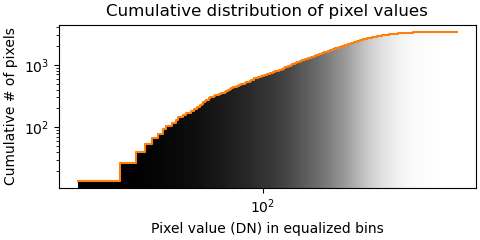

In [21]:
test_cut_out_map